# Visualizaciones de datos

In [3]:
import pandas as pd

## Grafica de barras

* Magnitud vs proporción

Es recomendable para cambios de magnitud para valores absolutos

Donde no podría usar una grafica de barras:

* Cuando tengamos muchas categorías a comparar
* Si quiero analizar riesgos individuales de un dataset y existan muchos registros
* Si quiero comparar proporciones (se podría usar graficas de pastel o de otro tipo)
* Si me interesa investigar acerca de la distribución de mis datos

In [6]:
df  = pd.read_csv('datasets/titanic-barras.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
len(df)

891

### Ejercicio

* Objetivo: Visualizar cuantos pasajeros hombres y cuantas pasajeras mujeres habian en el titanic

In [20]:
agrupados_pasajeros =df.groupby('Sex').agg({'PassengerId':'count'})

agrupados_pasajeros

,PassengerId
Sex,
female,314
male,577


### usando pandas

<Axes: title={'center': 'Cantidad de pasajeros por sexo'}, xlabel='Sex'>

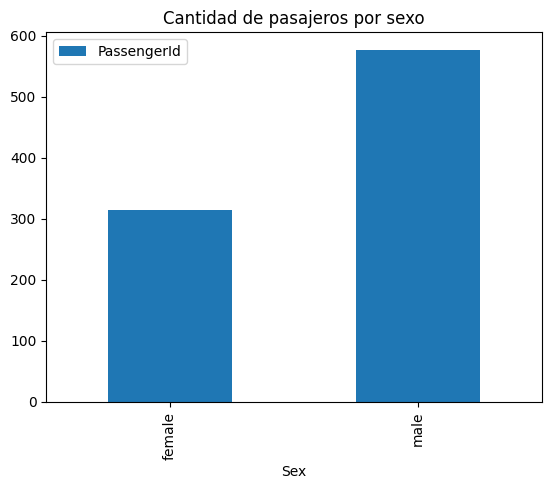

In [14]:
agrupados_pasajeros.plot.bar(
    y = 'PassengerId',
    title = 'Cantidad de pasajeros por sexo',
    width = 0.5
)

### Usando Seaborn

In [15]:
import seaborn as sns

* Seaborn no identifica el data frame directamente, es decir, se debe procesar el DF para que use únicamente columnas, no puede usar directamente los index como lo usa Pandas

In [21]:
pasajeros = agrupados_pasajeros.reset_index()
pasajeros

,Sex,PassengerId
0,female,314
1,male,577


<Axes: xlabel='Sex', ylabel='PassengerId'>

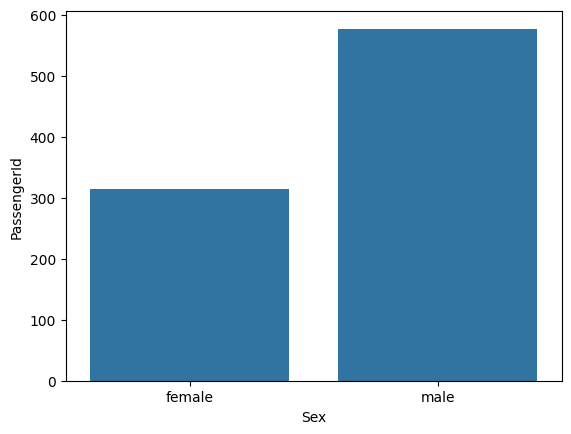

In [23]:
sns.barplot(
    pasajeros,
    x = 'Sex',
    y = 'PassengerId'
)

### Usando Matplotlib

In [24]:
import matplotlib.pyplot as plt

<BarContainer object of 2 artists>

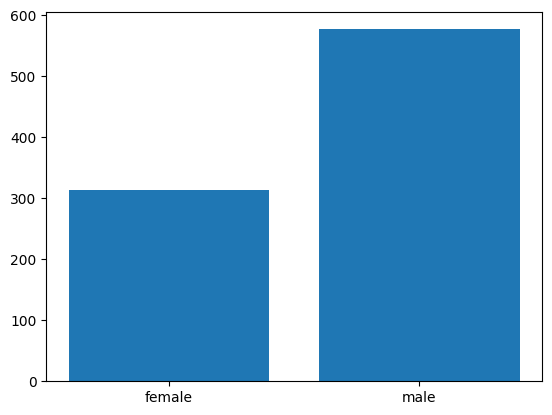

In [25]:
plt.bar(
    pasajeros['Sex'],
    pasajeros['PassengerId']
)

### Grafico de Pastel

#Summary:
Representa una parte porcentual de un todo, es decir, se recomienda usar únicamente en realizar una comparación de una parcentual de un todo. NO SE USA cuando se requiera comparar magnitudes.

In [1]:
import pandas as pd

df = pd.read_csv('datasets/titanic-barras.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
pasajeros = df.groupby('Sex').agg({'PassengerId':'count'}).reset_index()

pasajeros

,Sex,PassengerId
0,female,314
1,male,577


<Axes: >

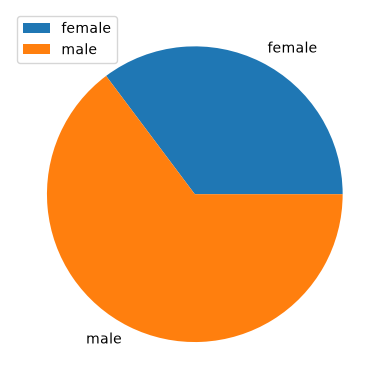

In [25]:

pasajeros.plot.pie(
    y = 'PassengerId')

In [26]:
import plotly.express as px

In [27]:
pasajeros2 = pasajeros.reset_index()

In [28]:
figura = px.pie(
    pasajeros2,
    names = 'Sex',
    values = 'PassengerId',
    title = 'Cantidad de pasajeros por sexo'
)

figura.show()

### Ejercicio

* Objetivo: Visualizar qué proporción de pasajeros viajaba en cada clase del Titanic (`Pclass`: 1ra, 2da, 3ra), usando un gráfico de pastel o de dona.

Ten en cuenta la definición vista arriba: el pastel/dona sirve para mostrar **partes de un todo en porcentaje**, no para comparar magnitudes absolutas. `Pclass` es un buen candidato porque tiene pocas categorías (3) y lo que interesa es qué parte del total representa cada una — a diferencia de columnas como `Fare` o `Age`, donde no aplicaría.

Pasos sugeridos:

1. Agrupa `df` por `Pclass` y cuenta pasajeros (`PassengerId`).
2. Grafica un pastel con `.plot.pie(...)`, mostrando el porcentaje de cada clase con `autopct='%1.1f%%'`.
3. Bonus (dona): convierte el pastel en dona agregando un círculo blanco en el centro con `plt.gca().add_artist(plt.Circle((0,0), 0.7, color='white'))`, o usando `wedgeprops=dict(width=0.4)` en `plt.pie`.
4. Reflexiona: ¿por qué no tendría sentido hacer este mismo gráfico para comparar, por ejemplo, la tarifa (`Fare`) promedio por clase?